<a href="https://colab.research.google.com/github/Madathanapalleleena/DL_exploration/blob/main/DL_text_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn

# Sample sentence
text = "i love machine learning i love deep learning"

# Tokenization (word-level)
words = text.split()
vocab = list(set(words))

word2idx = {w:i for i,w in enumerate(vocab)}
idx2word = {i:w for w,i in word2idx.items()}

# Prepare dataset
seq_length = 2
X, y = [], []

for i in range(len(words) - seq_length):
    X.append([word2idx[w] for w in words[i:i+seq_length]])
    y.append(word2idx[words[i+seq_length]])

X = torch.tensor(X)
y = torch.tensor(y)

# Model
class WordRNN(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 10)
        self.rnn = nn.RNN(10, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

model = WordRNN(len(vocab), 16)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Train
for epoch in range(200):
    output = model(X)
    loss = loss_fn(output, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

#Prediction example
test = ["i", "love"]
inp = torch.tensor([[word2idx[w] for w in test]])

pred = model(inp).argmax().item()
print("Next word:", idx2word[pred])

Next word: machine


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

text = """
i love machine learning
i love deep learning
i love artificial intelligence
machine learning is fun
deep learning is powerful
ai is the future
"""

# Tokenization
words = text.lower().split()
vocab = list(set(words))

word2idx = {w:i for i,w in enumerate(vocab)}
idx2word = {i:w for w,i in word2idx.items()}

vocab_size = len(vocab)
# 2. Prepare sequences

seq_length = 2
X, y = [], []

for i in range(len(words) - seq_length):
    X.append([word2idx[words[i]], word2idx[words[i+1]]])
    y.append(word2idx[words[i+2]])

X = torch.tensor(X)
y = torch.tensor(y)

# -----------------------------
# 3. LSTM Model
# -----------------------------
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_size=10, hidden_size=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

model = LSTMModel(vocab_size)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# -----------------------------
# 4. Training
# -----------------------------
for epoch in range(1000):
    output = model(X)
    loss = loss_fn(output, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# -----------------------------
# 5. Sampling function (IMPORTANT)
# -----------------------------
def sample(logits):
    probs = F.softmax(logits, dim=-1)
    return torch.multinomial(probs, 1).item()

# -----------------------------
# 6. Sentence Generator
# -----------------------------
def generate_sentence(model, start_words, length=6):
    model.eval()
    words_gen = start_words.copy()

    for _ in range(length):
        inp = torch.tensor([[word2idx[w] for w in words_gen[-2:]]])
        logits = model(inp)
        pred = sample(logits)
        words_gen.append(idx2word[pred])

    return " ".join(words_gen)

# -----------------------------
# 7. Example Prediction
# -----------------------------
print("\nGenerated Sentence:")
print(generate_sentence(model, ["i", "love"], length=8))

Epoch 0, Loss: 2.6056
Epoch 200, Loss: 0.3396
Epoch 400, Loss: 0.3390
Epoch 600, Loss: 0.3389
Epoch 800, Loss: 0.3389

Generated Sentence:
i love deep learning i love artificial intelligence machine learning


In [ ]:
import torch
import torch.nn as nn

# Sample model using LSTM
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


# Sample model using GRU
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])


# Dummy input: (batch, sequence_length, features)
x = torch.randn(4, 10, 8)

lstm_model = LSTMModel(8, 16, 2)
gru_model  = GRUModel(8, 16, 2)

print("LSTM output:", lstm_model(x))
print("GRU output :", gru_model(x))

LSTM output: tensor([[-0.1787,  0.0372],
        [-0.0247,  0.0762],
        [-0.0397,  0.0610],
        [-0.1668, -0.0160]], grad_fn=<AddmmBackward0>)
GRU output : tensor([[ 0.0753,  0.0736],
        [-0.0320, -0.1991],
        [ 0.1519, -0.3222],
        [ 0.1485, -0.1864]], grad_fn=<AddmmBackward0>)


LSTM
* Uses cell state + hidden state
* Better at capturing very long-term dependencies
* Handles vanishing gradient problem well
* Slightly heavier (more parameters)

GRU
* Uses reset gate + update gate
* Simpler than LSTM (fewer parameters)
* Trains faster
* Performs almost similar to LSTM in many tasks

In [ ]:
import torch
import torch.nn as nn

# ---------------- Encoder ----------------
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)

    def forward(self, x):
        _, hidden = self.gru(x)
        return hidden


# ---------------- Decoder ----------------
class Decoder(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, hidden):
        out, hidden = self.gru(x, hidden)
        out = self.fc(out)
        return out, hidden


# ---------------- Seq2Seq ----------------
class Seq2Seq(nn.Module):
    def __init__(self, enc, dec):
        super().__init__()
        self.encoder = enc
        self.decoder = dec

    def forward(self, src, tgt):
        hidden = self.encoder(src)
        out, _ = self.decoder(tgt, hidden)
        return out


# ---------------- Toy Data ----------------
src = torch.tensor([[[1.],[2.],[3.]]], dtype=torch.float)
tgt = torch.tensor([[[4.],[5.],[6.]]], dtype=torch.float)

# ---------------- Model ----------------
enc = Encoder(1, 8)
dec = Decoder(1, 8, 1)
model = Seq2Seq(enc, dec)

# ---------------- Training (IMPORTANT FIX) ----------------
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(200):
    optimizer.zero_grad()

    output = model(src, tgt)
    loss = criterion(output, tgt)

    loss.backward()
    optimizer.step()

# ---------------- Result ----------------
print("Loss:", loss.item())
print("Predicted output:\n", model(src, tgt).detach().numpy())

Loss: 0.2381782978773117
Predicted output:
 [[[4.363083 ]
  [5.0418496]
  [5.245411 ]]]


The model learns a mapping from input sequence to output sequence (e.g., [1,2,3] → [4,5,6]) after training.

The encoder compresses the entire input into a fixed-size context vector (hidden state).

The decoder uses this context to generate the target sequence step-by-step.
Before training, outputs are random; after training, outputs become close to target values.

The model can handle variable-length sequences, making it suitable for translation tasks.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# -------- Encoder --------
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)

    def forward(self, x):
        outputs, hidden = self.gru(x)
        return outputs, hidden


# -------- Attention --------
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()

    def forward(self, hidden, encoder_outputs):
        # hidden: (1, batch, hidden)
        # encoder_outputs: (batch, seq_len, hidden)

        hidden = hidden.permute(1, 2, 0)  # (batch, hidden, 1)
        scores = torch.bmm(encoder_outputs, hidden)  # (batch, seq_len, 1)

        weights = F.softmax(scores, dim=1)  # attention weights

        context = torch.sum(weights * encoder_outputs, dim=1, keepdim=True)
        return context  # (batch, 1, hidden)


# -------- Decoder --------
class Decoder(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.gru = nn.GRU(input_size + hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, hidden, encoder_outputs, attention):
        context = attention(hidden, encoder_outputs)

        # ✅ FIX: match sequence length
        context = context.repeat(1, x.size(1), 1)

        x = torch.cat([x, context], dim=2)

        out, hidden = self.gru(x, hidden)
        out = self.fc(out)
        return out, hidden


# -------- Seq2Seq --------
class Seq2Seq(nn.Module):
    def __init__(self, enc, dec, attn):
        super().__init__()
        self.encoder = enc
        self.decoder = dec
        self.attn = attn

    def forward(self, src, tgt):
        enc_out, hidden = self.encoder(src)
        out, _ = self.decoder(tgt, hidden, enc_out, self.attn)
        return out


# -------- Dummy Data --------
src = torch.randn(1, 3, 1)
tgt = torch.randn(1, 3, 1)

# -------- Model --------
enc = Encoder(1, 8)
attn = Attention(8)
dec = Decoder(1, 8, 1)

model = Seq2Seq(enc, dec, attn)

# -------- Run --------
output = model(src, tgt)

print("Output:\n", output.detach().numpy())

Output:
 [[[0.35199627]
  [0.28792465]
  [0.21618237]]]


Attention allows the decoder to focus on relevant parts of the input sequence instead of relying on a single context vector.

It computes attention weights, which indicate the importance of each input token during decoding.

Improves performance for long sequences, where basic Seq2Seq fails.
Helps solve the information bottleneck problem in encoder–decoder models.

Makes translation more accurate by aligning input words with output words.

In [ ]:
import torch
import torch.nn as nn

class TransformerModel(nn.Module):
    def __init__(self, vocab_size, d_model=128, nhead=4, num_layers=2):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, d_model)

        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers
        )

        self.fc = nn.Linear(d_model, vocab_size)

    def forward(self, src, tgt):
        src = self.embedding(src)
        tgt = self.embedding(tgt)

        output = self.transformer(src, tgt)
        return self.fc(output)

In [ ]:
from transformers import BertTokenizer, BertForMaskedLM
import torch

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertForMaskedLM.from_pretrained("bert-base-uncased")

sentence = "The capital of India is [MASK]."

inputs = tokenizer(sentence, return_tensors="pt")
with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits

mask_index = torch.where(inputs.input_ids == tokenizer.mask_token_id)[1]

predicted_id = logits[0, mask_index].argmax(dim=-1)
print("Prediction:", tokenizer.decode(predicted_id))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Prediction: mumbai


In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

text = "This product is amazing and works perfectly!"

inputs = tokenizer(text, return_tensors="pt", truncation=True)

with torch.no_grad():
    outputs = model(**inputs)

pred = torch.argmax(outputs.logits)
print("Sentiment:", "Positive" if pred==1 else "Negative")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Sentiment: Negative


In [ ]:
import torch
import torch.nn as nn

class ViT(nn.Module):
    def __init__(self, img_size=28, patch_size=7, dim=128, num_classes=10):
        super().__init__()

        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2

        self.patch_embed = nn.Linear(patch_size * patch_size, dim)

        self.pos_embedding = nn.Parameter(torch.randn(1, self.num_patches, dim))

        encoder_layer = nn.TransformerEncoderLayer(d_model=dim, nhead=4)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        self.fc = nn.Linear(dim, num_classes)

    def forward(self, x):
        # x: (B, 1, 28, 28)
        B = x.shape[0]

        x = x.unfold(2, 7, 7).unfold(3, 7, 7)
        x = x.contiguous().view(B, -1, 7*7)

        x = self.patch_embed(x)
        x = x + self.pos_embedding

        x = self.transformer(x)
        x = x.mean(dim=1)

        return self.fc(x)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
(1, 784)


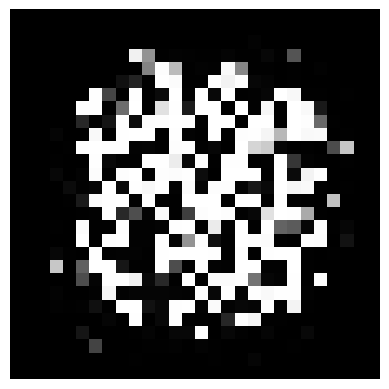

In [ ]:
import tensorflow as tf
import numpy as np

# data
(x_train,_),_ = tf.keras.datasets.mnist.load_data()
x_train = x_train.reshape(-1,784)/255.0

# generator
generator = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_dim=100),
    tf.keras.layers.Dense(784, activation='sigmoid')
])

# discriminator
discriminator = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_dim=784),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

discriminator.compile('adam','binary_crossentropy')

# GAN
discriminator.trainable = False
z = tf.keras.Input(shape=(100,))
gan = tf.keras.Model(z, discriminator(generator(z)))
gan.compile('adam','binary_crossentropy')

# training (minimal)
for _ in range(500):
    idx = np.random.randint(0, x_train.shape[0], 32)
    real = x_train[idx]

    noise = np.random.normal(0,1,(32,100))
    fake = generator.predict(noise, verbose=0)

    discriminator.trainable = True
    discriminator.train_on_batch(real, np.ones((32,1)))
    discriminator.train_on_batch(fake, np.zeros((32,1)))

    discriminator.trainable = False
    gan.train_on_batch(noise, np.ones((32,1)))

# generate sample
img = generator.predict(np.random.normal(0,1,(1,100)))
print(img.shape)

import matplotlib.pyplot as plt

plt.imshow(img.reshape(28,28), cmap='gray')
plt.axis('off')
plt.show()